In [68]:
# 1. Préparation et nettoyage des données

## 1.1 Importation des librairies et chargement des fichiers bruts
# Importation des librairies standards pour la manipulation et la visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

# Chargement des données brutes (le séparateur est un point-virgule)
customers = pd.read_csv('customers.csv', sep=";")
products = pd.read_csv('products.csv', sep=";")
transactions = pd.read_csv('Transactions.csv', sep=";")

# Aperçu des 5 premières lignes pour valider la bonne lecture des colonnes
display(customers.head())
display(products.head())
display(transactions.head())


/tmp/ipykernel_444/3069290627.py:14: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv('Transactions.csv', sep=";")


,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033


In [69]:
## 1.2 Audit de la base Clients

# 1. Table Customers
# Analyse de la structure et du volume des données clients
print("--- CUSTOMERS ---")
print(customers.info())

# Contrôle qualité : recherche de lignes dupliquées et de champs vides
print("Doublons :", customers.duplicated().sum())
print("Valeurs manquantes :\n", customers.isnull().sum())

--- CUSTOMERS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB
None
Doublons : 0
Valeurs manquantes :
 client_id    0
sex          0
birth        0
dtype: int64


In [70]:
## 1.3 Transformation : Calcul de l'âge des clients
# Définition de l'année de référence correspondant à la période des ventes
annee_analyse = 2021

# Création de la colonne 'age' par simple soustraction mathématique
customers['age'] = annee_analyse - customers['birth']

In [71]:
## 1.4 Audit de la base Produits
# Analyse de la structure et du volume du catalogue
print("\n--- PRODUCTS ---")
print(products.info())

# Contrôle de l'intégrité : vérification de l'unicité et de la complétude
print("Doublons :", products.duplicated().sum())
print("Valeurs manquantes :\n", products.isnull().sum())


--- PRODUCTS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB
None
Doublons : 0
Valeurs manquantes :
 id_prod    0
price      0
categ      0
dtype: int64


In [72]:
## 1.5 Contrôle des anomalies de prix
# Recherche et comptage des produits dont le prix est inférieur ou égal à zéro
anomalies_prix = products[products['price'] <= 0].shape[0]

print(f"Produits avec prix négatifs ou nuls : {anomalies_prix}")

Produits avec prix négatifs ou nuls : 0


In [73]:
## 1.6 Audit de la base Transactions
# Analyse de la structure, du volume et du type de données des transactions
print("\n--- TRANSACTIONS ---")
print(transactions.info())


--- TRANSACTIONS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB
None


In [74]:
## 1.7 Nettoyage : Suppression des lignes vides
# Suppression stricte des lignes où toutes les valeurs sont manquantes (NaN)
transactions = transactions.dropna(how='all')

# Vérification du nouveau volume pour confirmer le nettoyage
print(f"Nombre de lignes après suppression des vides : {transactions.shape[0]}")

Nombre de lignes après suppression des vides : 687534


In [75]:
## 1.8 Conversion temporelle des transactions
# Conversion de la variable texte en véritable objet temporel
transactions['date'] = pd.to_datetime(transactions['date'])

# Contrôle qualité : vérification de l'absence d'erreurs de conversion (Not a Time)
erreurs_date = transactions['date'].isnull().sum()
print(f"Dates non converties (NaT) : {erreurs_date}")

Dates non converties (NaT) : 0


In [76]:
## 1.9 Consolidation : Jointures et création de la base d'analyse

# 1. Première jointure : enrichissement des transactions avec les prix et catégories
# La clé de liaison est l'identifiant du produit. La transaction reste la table maître (left).
df_ventes = pd.merge(transactions, products, on='id_prod', how='left')

# 2. Seconde jointure : ajout des informations démographiques
# La clé de liaison est l'identifiant client.
df_final = pd.merge(df_ventes, customers, on='client_id', how='left')

# 3. Contrôle d'intégrité post-jointure
# L'objectif est de vérifier l'absence de duplication ou de perte de lignes.
print(f"Nombre de transactions initiales : {transactions.shape[0]}")
print(f"Nombre de lignes dans le fichier final : {df_final.shape[0]}")

# Aperçu du jeu de données final consolidé
display(df_final.head())

Nombre de transactions initiales : 687534
Nombre de lignes dans le fichier final : 687534


,id_prod,date,session_id,client_id,price,categ,sex,birth,age
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,54
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,61
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,33
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989,32
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956,65


In [77]:
## 1.10 Validation de la jointure et audit final

# Recherche de valeurs nulles potentiellement générées par la jointure
print("\n--- AUDIT DES VALEURS MANQUANTES ---")
print(df_final.isnull().sum())


--- AUDIT DES VALEURS MANQUANTES ---
id_prod       0
date          0
session_id    0
client_id     0
price         0
categ         0
sex           0
birth         0
age           0
dtype: int64


In [78]:
# 2. Analyse des indicateurs de ventes

## 2.1 Calcul du CA global
# Agrégation financière : somme de la colonne 'price' de toutes les transactions
ca_total = df_final['price'].sum()

# Affichage du résultat avec formatage des milliers
print(f"Le CA est de : {ca_total:,.2f} €")

Le CA est de : 12,027,663.10 €


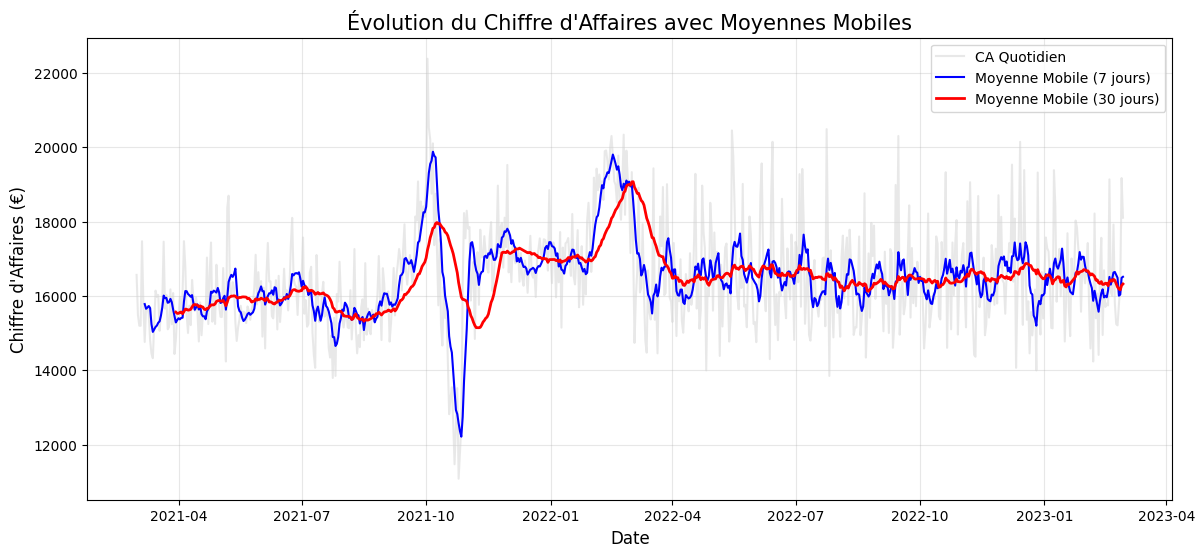

In [79]:
## 2.2 Évolution temporelle et lissage (Moyenne Mobile)

# 1. Agrégation temporelle : calcul du Chiffre d'Affaires total pour chaque jour
df_final['date_jour'] = df_final['date'].dt.date
ca_jour = df_final.groupby('date_jour')['price'].sum().reset_index()

# 2. Lissage mathématique : calcul des moyennes mobiles
# La fonction 'rolling' crée une fenêtre glissante sur les X derniers jours
ca_jour['Moyenne_7j'] = ca_jour['price'].rolling(window=7).mean()
ca_jour['Moyenne_30j'] = ca_jour['price'].rolling(window=30).mean()

# 3. Tracé du graphique analytique
plt.figure(figsize=(14, 6))

# Les ventes réelles sont affichées en arrière-plan (gris transparent)
sns.lineplot(data=ca_jour, x='date_jour', y='price', color='lightgrey', label='CA Quotidien', alpha=0.5)

# Les moyennes lissées sont mises en évidence
sns.lineplot(data=ca_jour, x='date_jour', y='Moyenne_7j', color='blue', label='Moyenne Mobile (7 jours)')
sns.lineplot(data=ca_jour, x='date_jour', y='Moyenne_30j', color='red', label='Moyenne Mobile (30 jours)', linewidth=2)

plt.title("Évolution du Chiffre d'Affaires avec Moyennes Mobiles", fontsize=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Chiffre d'Affaires (€)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

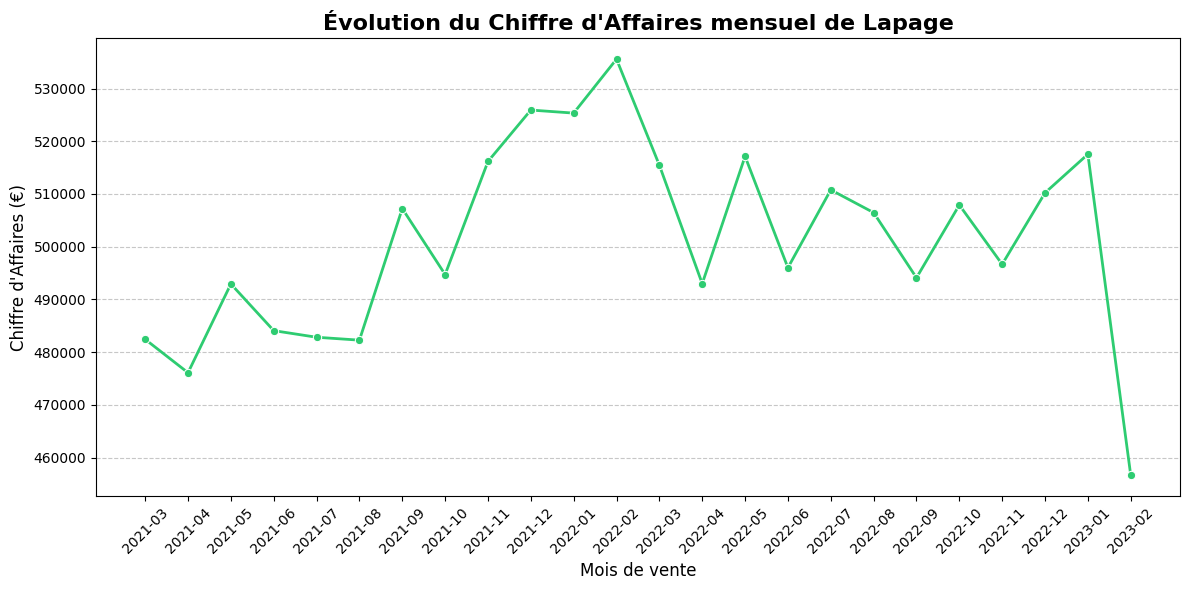

In [80]:
## 2.3 Analyse macro-économique : Évolution mensuelle du CA
# 1. Extraction de la période (Année-Mois) pour permettre l'agrégation
df_final['annee_mois'] = df_final['date'].dt.to_period('M')

# 2. Calcul du revenu total généré pour chaque mois
ca_mensuel = df_final.groupby('annee_mois')['price'].sum().reset_index()

# 3. Conversion au format texte pur pour stabiliser l'affichage de l'axe X sous Matplotlib
ca_mensuel['annee_mois'] = ca_mensuel['annee_mois'].astype(str)

# 4. Tracé de la courbe de tendance mensuelle
plt.figure(figsize=(12, 6))
sns.lineplot(data=ca_mensuel, x='annee_mois', y='price', marker='o', color='#2ecc71', linewidth=2)

# Formatage analytique du graphique
plt.title("Évolution du Chiffre d'Affaires mensuel de Lapage", fontsize=16, fontweight='bold')
plt.xlabel("Mois de vente", fontsize=12)
plt.ylabel("Chiffre d'Affaires (€)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [81]:
## 2.4 Audit de la complétude temporelle du mois de février
# 1. Isolement strict des transactions ayant eu lieu au mois de février
df_fevrier = df_final[df_final['date'].dt.month == 2].copy()

# 2. Extraction de la date pure (sans l'heure) pour le comptage
df_fevrier['jour_exact'] = df_fevrier['date'].dt.date

# 3. Calcul du nombre de jours uniques enregistrés et des bornes temporelles
jours_enregistres = df_fevrier['jour_exact'].nunique()
premier_jour = df_fevrier['jour_exact'].min()
dernier_jour = df_fevrier['jour_exact'].max()

# 4. Affichage factuel du résultat
print(f"Nombre total de jours d'activité enregistrés en février : {jours_enregistres}")
print(f"Le premier enregistrement date du : {premier_jour}")
print(f"Le dernier enregistrement date du : {dernier_jour}")

Nombre total de jours d'activité enregistrés en février : 56
Le premier enregistrement date du : 2022-02-01
Le dernier enregistrement date du : 2023-02-28


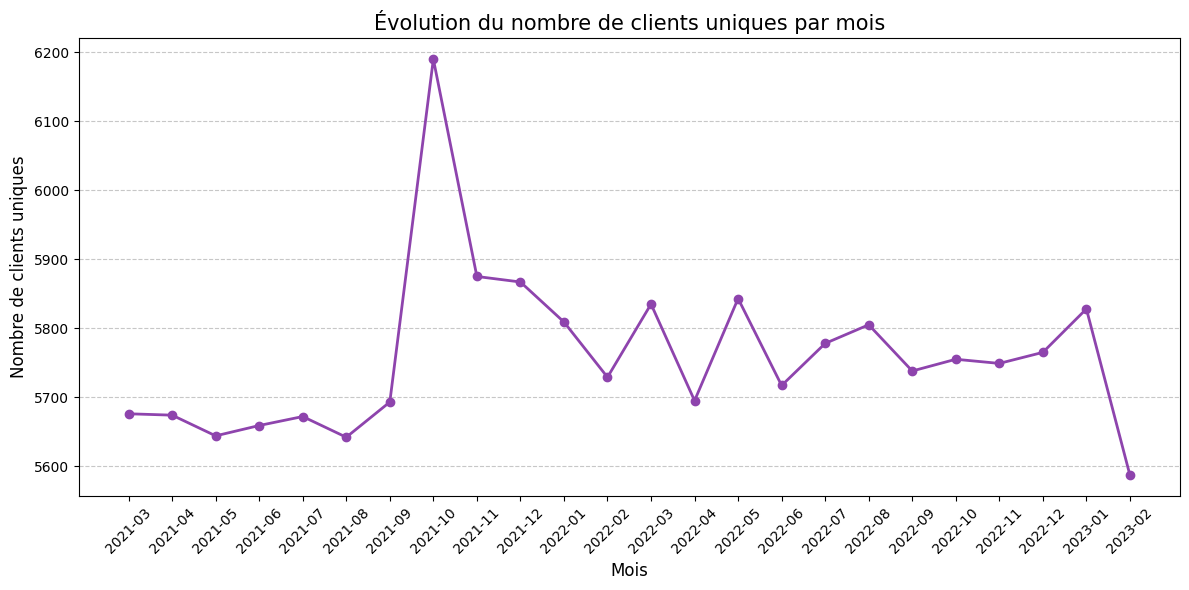

In [82]:
# 3. Analyse du comportement client

## 3.1 Évolution des acheteurs actifs par mois
# --- 1. Préparation ---
# On s'assure du format de la date et on extrait l'année-mois
df_final['date'] = pd.to_datetime(df_final['date'], errors='coerce')
df_final['annee_mois'] = df_final['date'].dt.to_period('M')

# Comptage des clients uniques par mois avec nunique()
# (si un client achète 3 fois dans le mois, il ne compte que pour 1)
clients_par_mois = df_final.groupby('annee_mois')['client_id'].nunique().reset_index()
clients_par_mois.columns = ['annee_mois', 'Nombre_de_clients_uniques']

# --- 2. Graphique ---
# Astuce : on passe la date en texte pour éviter les bugs d'axe X sous Matplotlib
clients_par_mois['annee_mois_str'] = clients_par_mois['annee_mois'].astype(str)

plt.figure(figsize=(12, 6))
plt.plot(clients_par_mois['annee_mois_str'], clients_par_mois['Nombre_de_clients_uniques'], marker='o', color='#8e44ad', linewidth=2)

plt.title("Évolution du nombre de clients uniques par mois", fontsize=15)
plt.xlabel("Mois", fontsize=12)
plt.ylabel("Nombre de clients uniques", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

APERÇU : TRANSACTIONS ET PRODUITS PAR MOIS
annee_mois_str  Nombre_Transactions  Nombre_Produits_Vendus
       2021-03                14201                   28601
       2021-04                13970                   28443
       2021-05                14168                   28285
       2021-06                13838                   26850
       2021-07                13571                   24738


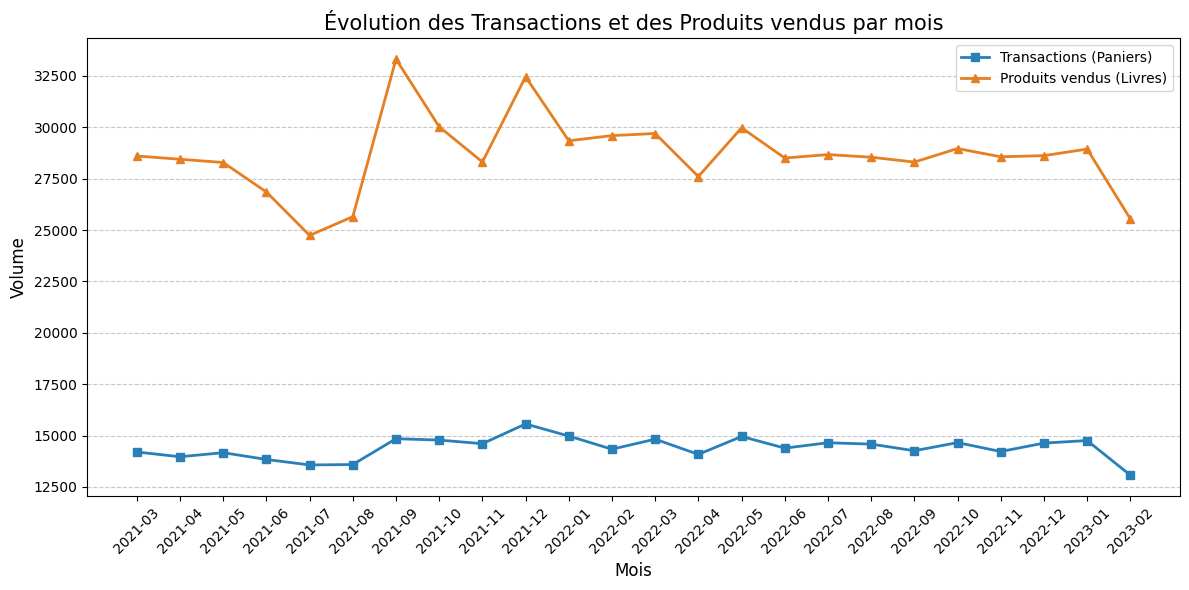

In [83]:
## 3.2 Évolution du volume de transactions et d'articles vendus
# --- 1. Préparation et Agrégation ---
# On s'assure que la colonne de regroupement est bien en format texte pour l'affichage
df_final['annee_mois_str'] = df_final['annee_mois'].astype(str)

# Double agrégation mensuelle :
# - nunique() sur session_id = 1 session équivaut à 1 panier/transaction validée
# - count() sur id_prod = compte chaque ligne de produit, soit le volume total de livres
ventes_mensuelles = df_final.groupby('annee_mois_str').agg(
    Nombre_Transactions=('session_id', 'nunique'),
    Nombre_Produits_Vendus=('id_prod', 'count')
).reset_index()

# Affichage de contrôle des données brutes
print("APERÇU : TRANSACTIONS ET PRODUITS PAR MOIS")
print(ventes_mensuelles.head().to_string(index=False))

# --- 2. Tracé du graphique ---
plt.figure(figsize=(12, 6))

# Courbe du nombre de paniers validés
plt.plot(ventes_mensuelles['annee_mois_str'], ventes_mensuelles['Nombre_Transactions'], marker='s', color='#2980b9', label='Transactions (Paniers)', linewidth=2)

# Courbe du volume total de livres vendus
plt.plot(ventes_mensuelles['annee_mois_str'], ventes_mensuelles['Nombre_Produits_Vendus'], marker='^', color='#e67e22', label='Produits vendus (Livres)', linewidth=2)

plt.title("Évolution des Transactions et des Produits vendus par mois", fontsize=15)
plt.xlabel("Mois", fontsize=12)
plt.ylabel("Volume", fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- ÉVOLUTION DU PANIER MOYEN EN EUROS ---
   Mois  Panier_Moyen_Euros
2021-03           33.972298
2021-04           34.080838
2021-05           34.792735
2021-06           34.982552
2021-07           35.578469




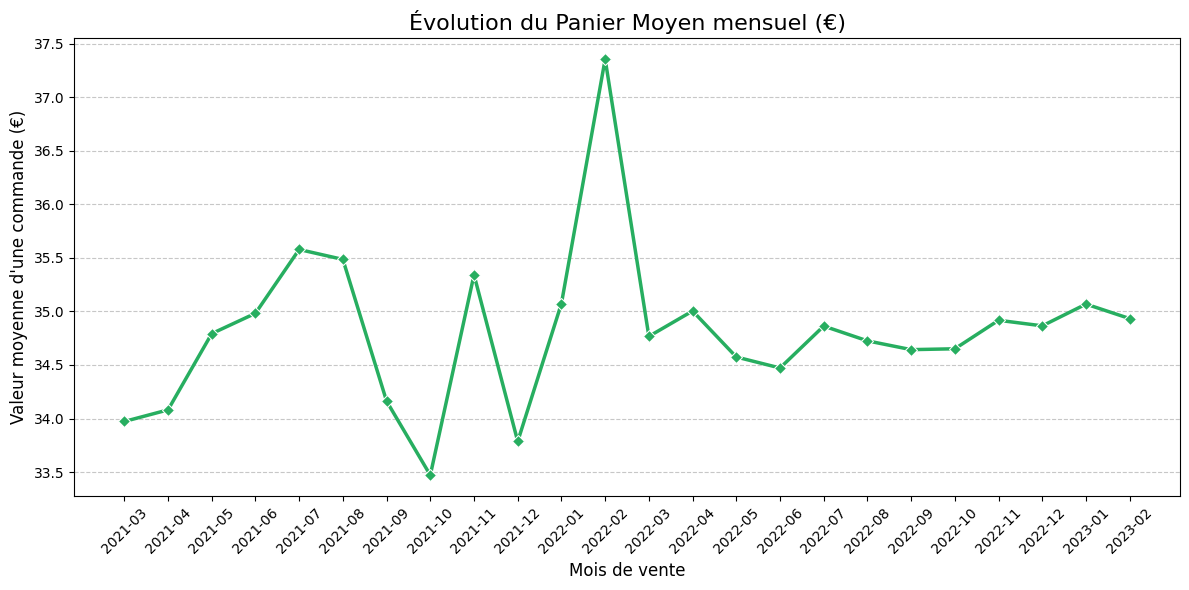

In [84]:

## 3.3 Évolution du panier moyen en valeur (€)

# --- 1. Calculs intermédiaires ---
# On calcule le CA total par mois et le nombre de paniers (sessions uniques)
ca_mensuel_valeur = df_final.groupby('annee_mois')['price'].sum()
transactions_mensuelles = df_final.groupby('annee_mois')['session_id'].nunique()

# --- 2. Calcul du Panier Moyen ---
# Formule stricte : CA total / Nombre de transactions
panier_moyen_mensuel = (ca_mensuel_valeur / transactions_mensuelles).reset_index()
panier_moyen_mensuel.columns = ['Mois', 'Panier_Moyen_Euros']

# Conversion du mois en texte pour l'affichage graphique
panier_moyen_mensuel['Mois'] = panier_moyen_mensuel['Mois'].astype(str)

# Affichage de contrôle
print("--- ÉVOLUTION DU PANIER MOYEN EN EUROS ---")
print(panier_moyen_mensuel.head().to_string(index=False))
print("\n")

# --- 3. Tracé du graphique ---
plt.figure(figsize=(12, 6))

# Courbe du panier moyen (en vert pour l'aspect financier)
sns.lineplot(data=panier_moyen_mensuel, x='Mois', y='Panier_Moyen_Euros', marker='D', color='#27ae60', linewidth=2.5)

plt.title("Évolution du Panier Moyen mensuel (€)", fontsize=16)
plt.xlabel("Mois de vente", fontsize=12)
plt.ylabel("Valeur moyenne d'une commande (€)", fontsize=12)

# Rotation des étiquettes de l'axe X pour la lisibilité
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

PRIX PAR CATÉGORIE
        count    mean    min     50%     max
categ                                       
0      2292.0   11.71   0.62   10.30   40.99
1       737.0   25.50   2.00   22.99   80.99
2       236.0  107.64  30.99  101.25  300.00

(Note : '50%' correspond à la médiane)


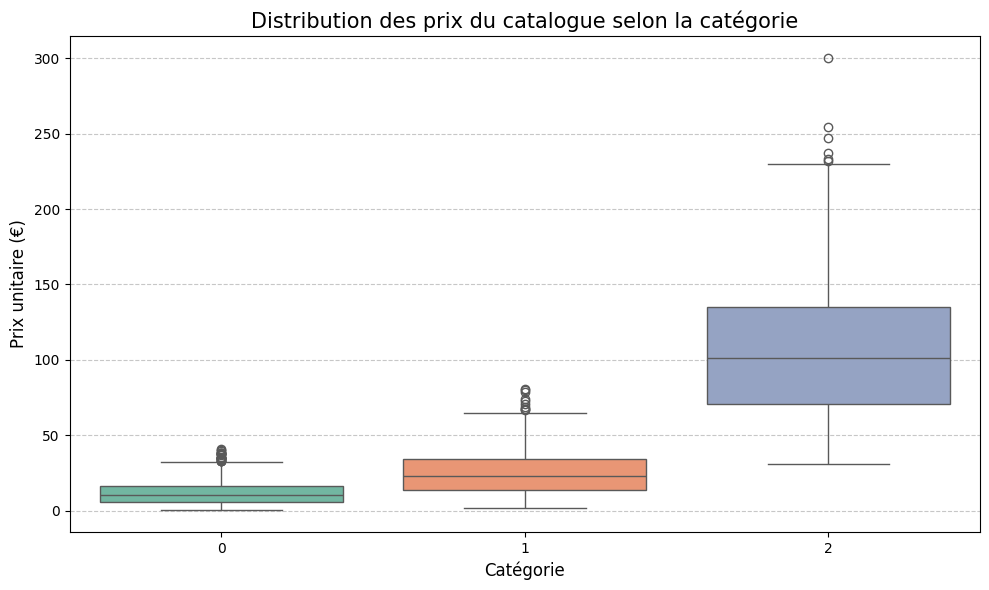

In [85]:
## 3.4 Analyse du catalogue et distribution des prix
# --- 1. Extraction du catalogue ---
# On isole chaque produit (id_prod) pour ne pas fausser les prix
# avec les volumes de ventes (1 produit = 1 ligne)
catalogue = df_final[['id_prod', 'price', 'categ']].drop_duplicates(subset=['id_prod'])

# Calcul des statistiques descriptives basiques
stats_prix = catalogue.groupby('categ')['price'].describe().round(2)

# Affichage de contrôle
print("PRIX PAR CATÉGORIE")
print(stats_prix[['count', 'mean', 'min', '50%', 'max']])
print("\n(Note : '50%' correspond à la médiane)")

# --- 2. Tracé du Boxplot ---
plt.figure(figsize=(10, 6))

# La boîte à moustaches est idéale pour voir la dispersion et les valeurs extrêmes
sns.boxplot(data=catalogue, x='categ', y='price', hue='categ', palette='Set2', legend=False)

plt.title("Distribution des prix du catalogue selon la catégorie", fontsize=15)
plt.xlabel("Catégorie", fontsize=12)
plt.ylabel("Prix unitaire (€)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

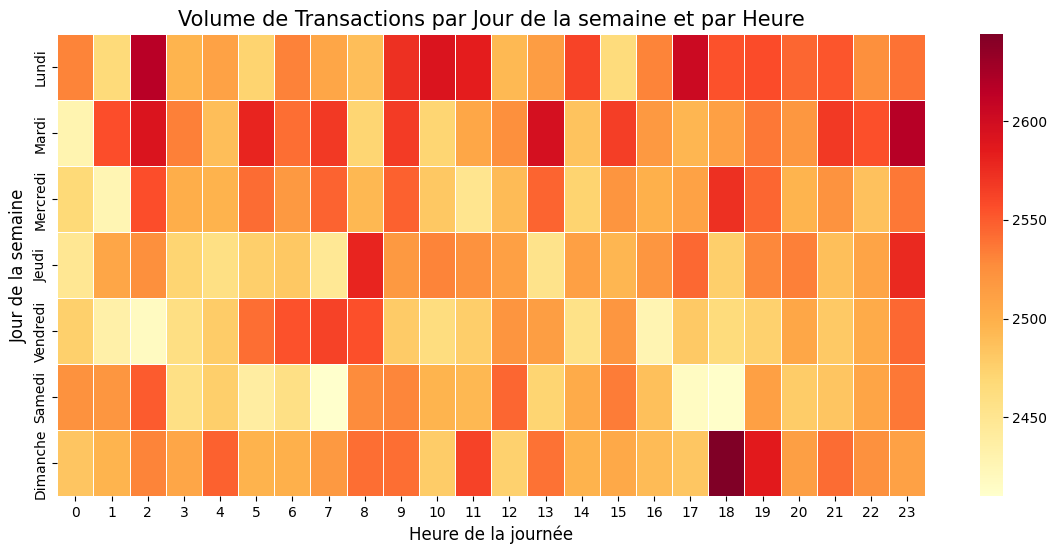

In [86]:
## 3.5 Analyse de l'affluence : Répartition horaire et hebdomadaire
# --- 1. Extraction temporelle ---
# On isole le jour de la semaine (0 = Lundi, 6 = Dimanche) et l'heure (0 à 23)
df_final['jour_semaine'] = df_final['date'].dt.dayofweek
df_final['heure'] = df_final['date'].dt.hour

# --- 2. Agrégation en matrice ---
# On compte les sessions uniques (paniers validés) par jour et par heure.
affluence_horaire = df_final.groupby(['jour_semaine', 'heure'])['session_id'].nunique().unstack()

# Remplacement des index numériques par les noms des jours pour la lisibilité
jours_noms = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
affluence_horaire.index = jours_noms

# --- 3. Tracé de la  Heatmap ---
plt.figure(figsize=(14, 6))

# La heatmap colore les cases selon le volume de transactions
sns.heatmap(affluence_horaire, cmap='YlOrRd', linewidths=.5)

plt.title("Volume de Transactions par Jour de la semaine et par Heure", fontsize=15)
plt.xlabel("Heure de la journée", fontsize=12)
plt.ylabel("Jour de la semaine", fontsize=12)

plt.show()

--- RÉPARTITION DU CHIFFRE D'AFFAIRES PAR CATÉGORIE ---
 categ      price  Part_du_CA (%)
     0 4419730.97           36.75
     1 4827657.11           40.14
     2 2780275.02           23.12


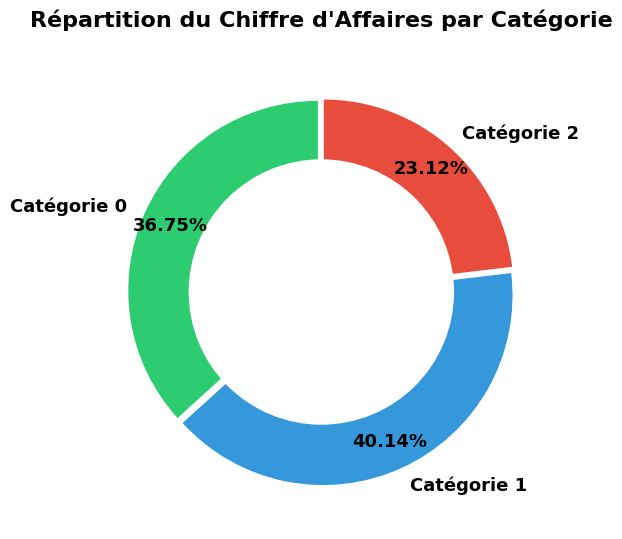

In [87]:
## 3.6 Répartition du Chiffre d'Affaires par catégorie
import matplotlib.pyplot as plt

# --- 1. Agrégation des revenus ---
# On regroupe les ventes par catégorie et on fait la somme des prix
ca_par_categ = df_final.groupby('categ')['price'].sum().reset_index()

# --- 2. Calcul des parts relatives ---
# On divise le CA de chaque catégorie par le CA global pour obtenir un pourcentage
ca_total = ca_par_categ['price'].sum()
ca_par_categ['Part_du_CA (%)'] = (ca_par_categ['price'] / ca_total * 100).round(2)

# Affichage propre des résultats dans la console
print("--- RÉPARTITION DU CHIFFRE D'AFFAIRES PAR CATÉGORIE ---")
print(ca_par_categ.to_string(index=False))

# --- 3. Tracé du graphique (Donut Chart) ---
plt.figure(figsize=(6, 6))

# Configuration des paramètres visuels
labels = ['Catégorie 0', 'Catégorie 1', 'Catégorie 2']
sizes = ca_par_categ['Part_du_CA (%)']
# Utilisation de couleurs professionnelles et contrastées
couleurs = ['#2ecc71', '#3498db', '#e74c3c']
# Détachement léger des parts pour plus de lisibilité
explode = (0.02, 0.02, 0.02)

# Création du diagramme circulaire de base
plt.pie(sizes, labels=labels, autopct='%1.2f%%', startangle=90,
        colors=couleurs, explode=explode, pctdistance=0.85,
        textprops={'fontsize': 13, 'fontweight': 'bold'})

# Ajout d'un cercle blanc au centre pour créer l'effet "Anneau" (Donut)
centre_cercle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_cercle)

# Titre et finalisation
plt.title("Répartition du Chiffre d'Affaires par Catégorie", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [88]:
## 3.7 Performances individuelles : Top 10 des produits
# --- 1. Calcul des performances par produit ---
# On groupe par référence produit (id_prod) pour consolider les ventes.
# - count() compte le nombre de fois où le livre a été scanné en caisse (Volume)
# - sum() additionne le prix pour donner le revenu total généré par ce livre (Valeur)
performances_produits = df_final.groupby('id_prod').agg(
    Quantite_Vendue=('id_prod', 'count'),
    Chiffre_Affaires_Euros=('price', 'sum')
).reset_index()

# --- 2. Extraction du Top 10 ---
# Tri décroissant sur le volume (du plus vendu au moins vendu)
tops_10 = performances_produits.sort_values(by='Quantite_Vendue', ascending=False).head(10)

# Note méthodologique : Les "flops" ne sont pas calculés ici.
# Le bas du classement ne remonterait que les livres vendus 1 seule fois,
# ignorant totalement les livres du catalogue n'ayant généré aucune vente.

# --- 3. Affichage des résultats ---
print("--- TOP 10 DES VENTES (Par volume) ---")
print(tops_10.to_string(index=False))
print("\n" + "="*40 + "\n")


--- TOP 10 DES VENTES (Par volume) ---
id_prod  Quantite_Vendue  Chiffre_Affaires_Euros
  1_369             2340                56136.60
  1_417             2269                47626.31
  1_414             2246                53522.18
  1_498             2202                51460.74
  1_425             2163                36749.37
  1_403             2040                36699.60
  1_413             2036                36627.64
  1_412             2014                33533.10
  1_406             2003                49694.43
  1_407             2001                31995.99




In [89]:
## 3.8 Identification des clients atypiques (profils B2B)

# --- 1. Agrégation par client ---
# On calcule la dépense totale de chaque client sur l'ensemble de la période
ca_total_client = df_final.groupby('client_id')['price'].sum().reset_index(name='CA_Total_Euros')

# --- 2. Tri et identification ---
# On trie du plus gros acheteur au plus petit pour faire remonter les anomalies
top_clients = ca_total_client.sort_values(by='CA_Total_Euros', ascending=False)

# --- 3. Affichage de contrôle ---
print("--- TOP 10 DES CLIENTS (Par Chiffre d'Affaires cumulé sur la période) ---")
print(top_clients.head(10).to_string(index=False))

--- TOP 10 DES CLIENTS (Par Chiffre d'Affaires cumulé sur la période) ---
client_id  CA_Total_Euros
   c_1609       326039.89
   c_4958       290227.03
   c_6714       153918.60
   c_3454       114110.57
   c_1570         5285.82
   c_3263         5276.87
   c_2140         5260.18
   c_2899         5214.05
   c_7319         5155.77
   c_7959         5135.75


--- RÉPARTITION DU CHIFFRE D'AFFAIRES : B2B vs B2C ---
type_client       price  Part_du_CA (%)
        B2B   884296.09            7.35
        B2C 11143367.01           92.65


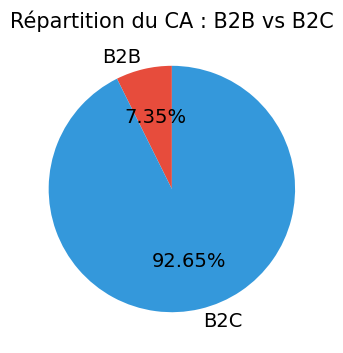

In [90]:
## 3.9 Catégorisation B2B / B2C et impact sur le chiffre d'affaires
# --- 1. Création du filtre B2B ---
# Liste stricte des 4 identifiants ayant des volumes d'achats anormaux
clients_b2b = ['c_1609', 'c_4958', 'c_6714', 'c_3454']

# Création d'une nouvelle colonne pour taguer chaque transaction
df_final['type_client'] = df_final['client_id'].apply(lambda x: 'B2B' if x in clients_b2b else 'B2C')

# --- 2. Calcul des parts de marché ---
# Agrégation du chiffre d'affaires selon ce nouveau tag
repartition_ca = df_final.groupby('type_client')['price'].sum().reset_index()
ca_total = repartition_ca['price'].sum()

# Calcul du pourcentage pour mesurer la dépendance
repartition_ca['Part_du_CA (%)'] = (repartition_ca['price'] / ca_total * 100).round(2)

print("--- RÉPARTITION DU CHIFFRE D'AFFAIRES : B2B vs B2C ---")
print(repartition_ca.to_string(index=False))

# --- 3. Tracé du graphique (Pie chart) ---
plt.figure(figsize=(4, 4))

# Couleurs contrastées : Rouge pour l'alerte B2B, Bleu pour le standard B2C
couleurs = ['#e74c3c', '#3498db']

# Le diagramme circulaire est idéal pour visualiser des parts d'un tout (100%)
plt.pie(repartition_ca['price'], labels=repartition_ca['type_client'], autopct='%1.2f%%',
        startangle=90, colors=couleurs, textprops={'fontsize': 14})

plt.title("Répartition du CA : B2B vs B2C", fontsize=15)
plt.show()

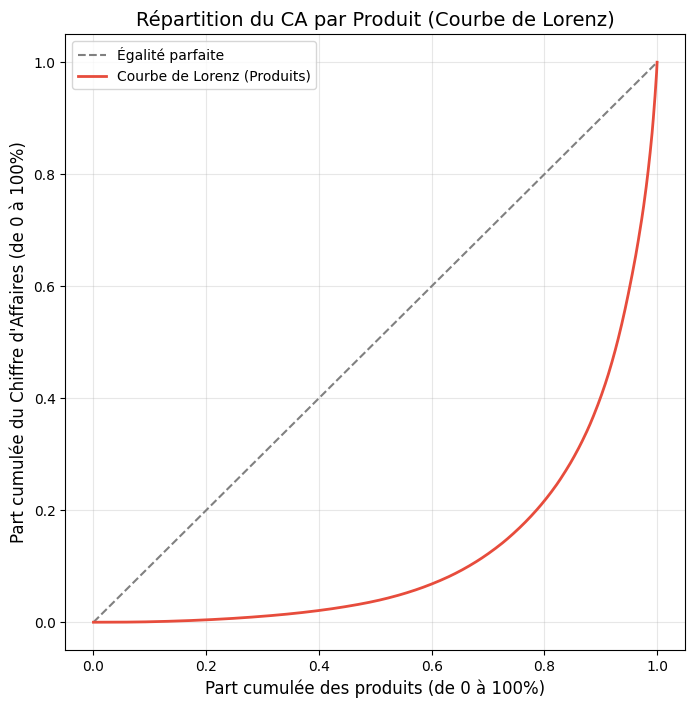

In [91]:
## 3.10 Concentration des ventes : Courbe de Lorenz (Produits)

# --- 1. Préparation des données pour la courbe ---
# On regroupe par produit et on fait la somme totale générée par chacun
ca_par_produit = df_final.groupby('id_prod')['price'].sum().values

# Règle mathématique stricte pour Lorenz : il faut trier les valeurs par ordre croissant
ca_par_produit_trie = np.sort(ca_par_produit)

# On calcule la part cumulée (somme cumulée divisée par la somme totale)
lorenz_produits = np.cumsum(ca_par_produit_trie) / ca_par_produit_trie.sum()

# On ajoute un 0 au début du tableau pour forcer la courbe à partir de l'origine (0,0)
lorenz_produits = np.append([0], lorenz_produits)

# --- 2. Tracé du graphique ---
plt.figure(figsize=(8, 8))

# Tracé de la bissectrice (la droite théorique où tous les produits se vendraient à égalité)
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Égalité parfaite')

# Tracé de notre véritable distribution (Courbe de Lorenz)
axe_x = np.linspace(0, 1, len(lorenz_produits))
plt.plot(axe_x, lorenz_produits, color='#e74c3c', linewidth=2, label='Courbe de Lorenz (Produits)')

plt.title("Répartition du CA par Produit (Courbe de Lorenz)", fontsize=14)
plt.xlabel("Part cumulée des produits (de 0 à 100%)", fontsize=12)
plt.ylabel("Part cumulée du Chiffre d'Affaires (de 0 à 100%)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [92]:
## 3.11 Mesure de la concentration : Indice de Gini
# --- 1. Mesure de l'aire sous la courbe ---
# Récupération du nombre d'éléments (produits)
n = len(ca_par_produit_trie)

# Calcul de l'aire sous la courbe de Lorenz via la méthode mathématique des trapèzes
aire_sous_courbe = np.trapezoid(lorenz_produits, dx=1/n)

# --- 2. Calcul de l'Indice ---
# Formule standard de Gini : 2 * (Aire sous la droite d'égalité parfaite - Aire sous la courbe)
# La surface sous la droite d'égalité parfaite est toujours de 0.5.
gini_produits = 2 * (0.5 - aire_sous_courbe)

# Affichage du résultat avec 3 décimales pour la précision
print(f"L'indice de Gini (répartition du CA par produit) est de : {gini_produits:.3f}")

L'indice de Gini (répartition du CA par produit) est de : 0.744


In [93]:
# 4. Analyses comportementales (Demandes de Julie)
## 4.1 Corrélation entre le genre du client et la catégorie d'achat

from scipy.stats import chi2_contingency

# --- 1. Préparation du périmètre (Filtre B2C) ---
# On exclut nos 4 profils atypiques (B2B) pour ne pas fausser l'étude
# du comportement des particuliers
clients_b2b = ['c_1609', 'c_4958', 'c_6714', 'c_3454']
df_b2c = df_final[~df_final['client_id'].isin(clients_b2b)]

# --- 2. Création du tableau de contingence ---
# On croise les deux variables qualitatives : le sexe et la catégorie
contingence = pd.crosstab(df_b2c['sex'], df_b2c['categ'])

# --- 3. Test statistique du Chi-2 ---
# La fonction compare nos ventes réelles avec une répartition théorique
# où le genre n'aurait aucune influence.
chi2_stat, p_value, dof, expected = chi2_contingency(contingence)

# Affichage des métriques brutes
print("--- RÉSULTAT DU TEST STATISTIQUE ---")
print(f"Statistique du Chi-2 : {chi2_stat:.2f}")
print(f"Valeur p (p-value) : {p_value}")

# --- 4. Interprétation automatisée ---
print("\nCONCLUSION :")
# Le seuil de significativité standard en statistiques est de 5% (0.05)
if p_value < 0.05:
    print("La p-value est inférieure à 0.05. Il existe un lien statistique prouvé entre le genre et la catégorie achetée.")
else:
    print("La p-value est supérieure à 0.05. Il n'y a PAS de lien statistique prouvé : hommes et femmes achètent les mêmes catégories dans des proportions similaires.")

--- RÉSULTAT DU TEST STATISTIQUE ---
Statistique du Chi-2 : 22.67
Valeur p (p-value) : 1.1955928116587024e-05

CONCLUSION :
La p-value est inférieure à 0.05. Il existe un lien statistique prouvé entre le genre et la catégorie achetée.


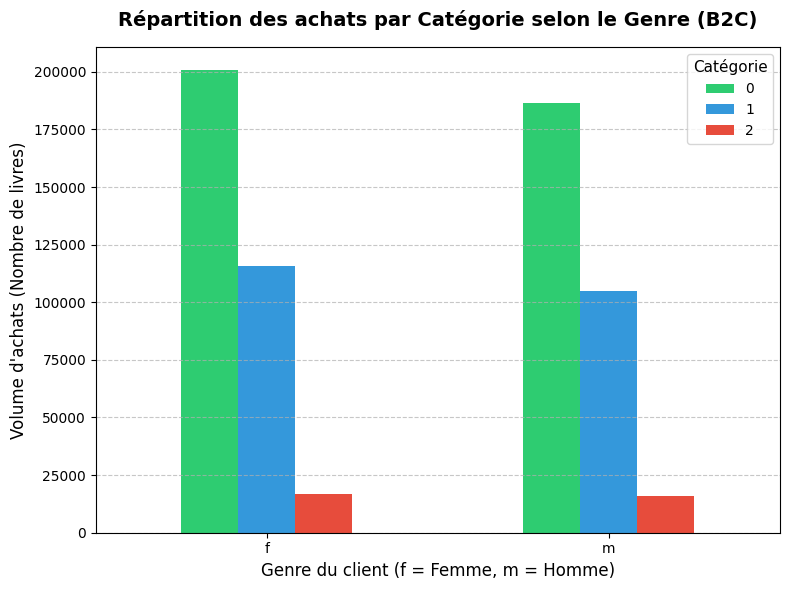

In [94]:
import matplotlib.pyplot as plt

# --- Tracé du graphique (Barres groupées) ---
# La variable 'contingence' contient déjà vos données croisées (Sexe vs Catégorie)
# On utilise la fonction .plot() intégrée à Pandas pour générer le graphique
contingence.plot(kind='bar', figsize=(8, 6), color=['#2ecc71', '#3498db', '#e74c3c'])

plt.title("Répartition des achats par Catégorie selon le Genre (B2C)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Genre du client (f = Femme, m = Homme)", fontsize=12)
plt.ylabel("Volume d'achats (Nombre de livres)", fontsize=12)

# On remet les étiquettes à l'horizontale pour la lisibilité
plt.xticks(rotation=0)
plt.legend(title="Catégorie", title_fontsize='11')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

--- RÉSULTAT DU TEST STATISTIQUE DE PEARSON ---
Coefficient de corrélation (r) : -0.1876
Valeur p (p-value) : 6.66e-69


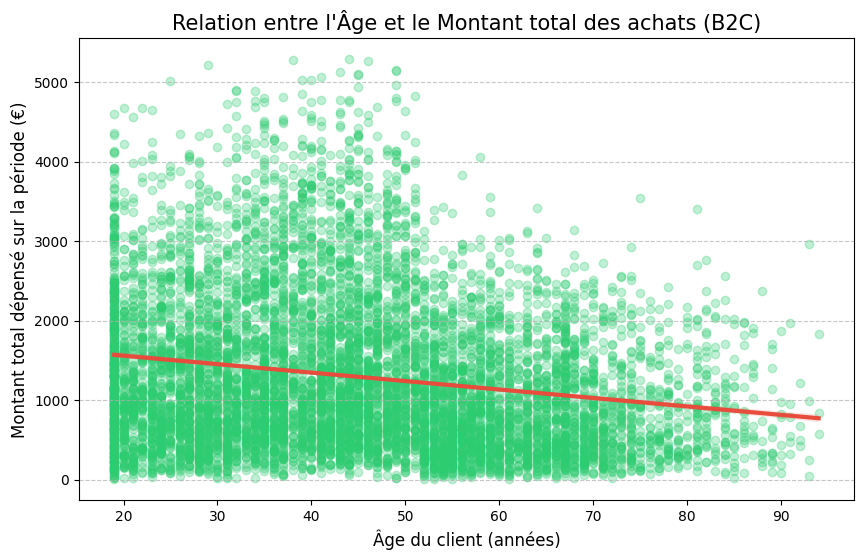

In [95]:
## 4.2 Relation entre l'âge des clients et le montant total des achats

# --- 1. Préparation des données (Filtre B2C et calcul de l'âge) ---
# On exclut strictement les clients professionnels
clients_b2b = ['c_1609', 'c_4958', 'c_6714', 'c_3454']
df_b2c = df_final[~df_final['client_id'].isin(clients_b2b)].copy()

# On calcule l'âge au moment de la dernière année d'exercice du jeu de données
annee_max = df_b2c['date'].dt.year.max()
df_b2c['age'] = annee_max - df_b2c['birth']

# On consolide le total dépensé par chaque client unique
achats_par_client = df_b2c.groupby('client_id').agg(
    age=('age', 'first'),
    montant_total=('price', 'sum')
).reset_index()

# --- 2. Test statistique de Pearson ---
# Le test évalue la corrélation linéaire entre deux variables quantitatives continues
r, p_value = st.pearsonr(achats_par_client['age'], achats_par_client['montant_total'])

print("--- RÉSULTAT DU TEST STATISTIQUE DE PEARSON ---")
print(f"Coefficient de corrélation (r) : {r:.4f}")
print(f"Valeur p (p-value) : {p_value:.2e}")

# --- 3. Tracé avec régression linéaire ---
plt.figure(figsize=(10, 6))

# regplot trace le nuage de points et superpose automatiquement la droite de tendance
sns.regplot(
    data=achats_par_client,
    x='age',
    y='montant_total',
    scatter_kws={'alpha': 0.3, 'color': '#2ecc71'},
    line_kws={'color': '#e74c3c', 'linewidth': 3}
)

plt.title("Relation entre l'Âge et le Montant total des achats (B2C)", fontsize=15)
plt.xlabel("Âge du client (années)", fontsize=12)
plt.ylabel("Montant total dépensé sur la période (€)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

--- RÉSULTAT DU TEST DE PEARSON ---
Coefficient de corrélation (r) : 0.1645
Valeur p (p-value) : 3.37e-53


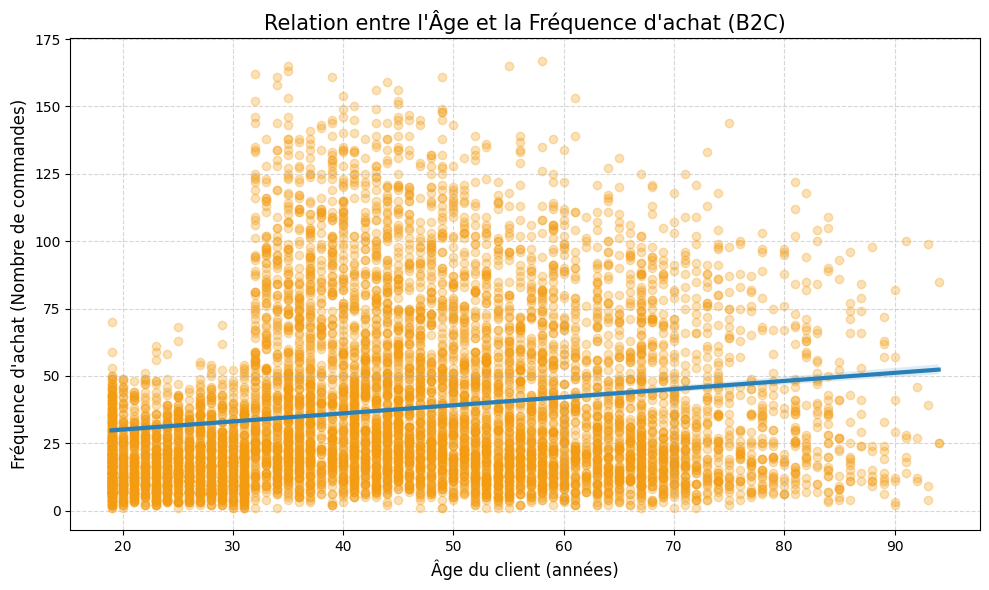

In [96]:
## 4.3 Relation entre l'âge des clients et la fréquence d'achat

# --- 1. Préparation du périmètre (Filtre B2C et âge) ---
# On s'assure de travailler uniquement sur les particuliers
clients_b2b = ['c_1609', 'c_4958', 'c_6714', 'c_3454']
df_b2c = df_final[~df_final['client_id'].isin(clients_b2b)].copy()

annee_max = df_b2c['date'].dt.year.max()
df_b2c['age'] = annee_max - df_b2c['birth']

# --- 2. Calcul de la fréquence d'achat ---
# On groupe par client pour calculer son âge et sa fréquence.
# L'utilisation de 'nunique' sur 'session_id' est cruciale : cela compte
# le nombre de passages en caisse, et non le nombre de livres achetés.
frequence_par_client = df_b2c.groupby('client_id').agg(
    age=('age', 'first'),
    frequence_achat=('session_id', 'nunique')
).reset_index()

# --- 3. Test statistique de Pearson ---
r_freq, p_value_freq = st.pearsonr(frequence_par_client['age'], frequence_par_client['frequence_achat'])

print("--- RÉSULTAT DU TEST DE PEARSON ---")
print(f"Coefficient de corrélation (r) : {r_freq:.4f}")
print(f"Valeur p (p-value) : {p_value_freq:.2e}")

# --- 4. Tracé avec régression linéaire ---
plt.figure(figsize=(10, 6))

sns.regplot(
    data=frequence_par_client,
    x='age',
    y='frequence_achat',
    scatter_kws={'alpha': 0.3, 'color': '#f39c12'},
    line_kws={'color': '#2980b9', 'linewidth': 3}
)

plt.title("Relation entre l'Âge et la Fréquence d'achat (B2C)", fontsize=15)
plt.xlabel("Âge du client (années)", fontsize=12)
plt.ylabel("Fréquence d'achat (Nombre de commandes)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

--- RÉSULTAT DU TEST DE PEARSON ---
Coefficient de corrélation (r) : -0.6165
Valeur p (p-value) : 0.00e+00


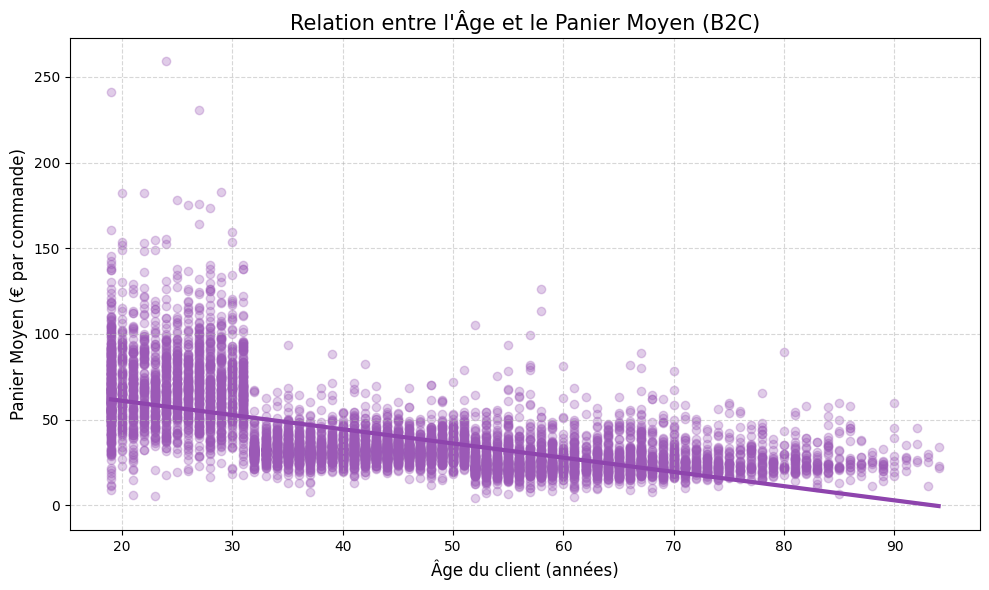

In [97]:
## 4.4 Relation entre l'âge des clients et la taille du panier moyen

# --- 1. Préparation du périmètre (Filtre B2C et calcul de l'âge) ---
clients_b2b = ['c_1609', 'c_4958', 'c_6714', 'c_3454']
df_b2c = df_final[~df_final['client_id'].isin(clients_b2b)].copy()

annee_max = df_b2c['date'].dt.year.max()
df_b2c['age'] = annee_max - df_b2c['birth']

# --- 2. Calcul des agrégats pour obtenir le panier moyen ---
# On récupère l'âge, la dépense totale et le nombre de passages en caisse par client
panier_par_client = df_b2c.groupby('client_id').agg(
    age=('age', 'first'),
    ca_total=('price', 'sum'),
    frequence_achat=('session_id', 'nunique')
).reset_index()

# Le panier moyen d'un client est la stricte division de son CA total
# par son nombre de commandes
panier_par_client['panier_moyen'] = panier_par_client['ca_total'] / panier_par_client['frequence_achat']

# --- 3. Test statistique de Pearson ---
r_panier, p_value_panier = st.pearsonr(panier_par_client['age'], panier_par_client['panier_moyen'])

print("--- RÉSULTAT DU TEST DE PEARSON ---")
print(f"Coefficient de corrélation (r) : {r_panier:.4f}")
print(f"Valeur p (p-value) : {p_value_panier:.2e}")

# --- 4. Tracé avec régression linéaire ---
plt.figure(figsize=(10, 6))

# Tracé des points et de la droite de tendance linéaire
sns.regplot(
    data=panier_par_client,
    x='age',
    y='panier_moyen',
    scatter_kws={'alpha': 0.3, 'color': '#9b59b6'},
    line_kws={'color': '#8e44ad', 'linewidth': 3}
)

plt.title("Relation entre l'Âge et le Panier Moyen (B2C)", fontsize=15)
plt.xlabel("Âge du client (années)", fontsize=12)
plt.ylabel("Panier Moyen (€ par commande)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

--- RÉSULTAT DU TEST ANOVA ---
Statistique de Fisher : 39705.52
Valeur p (p-value) : 0.00e+00


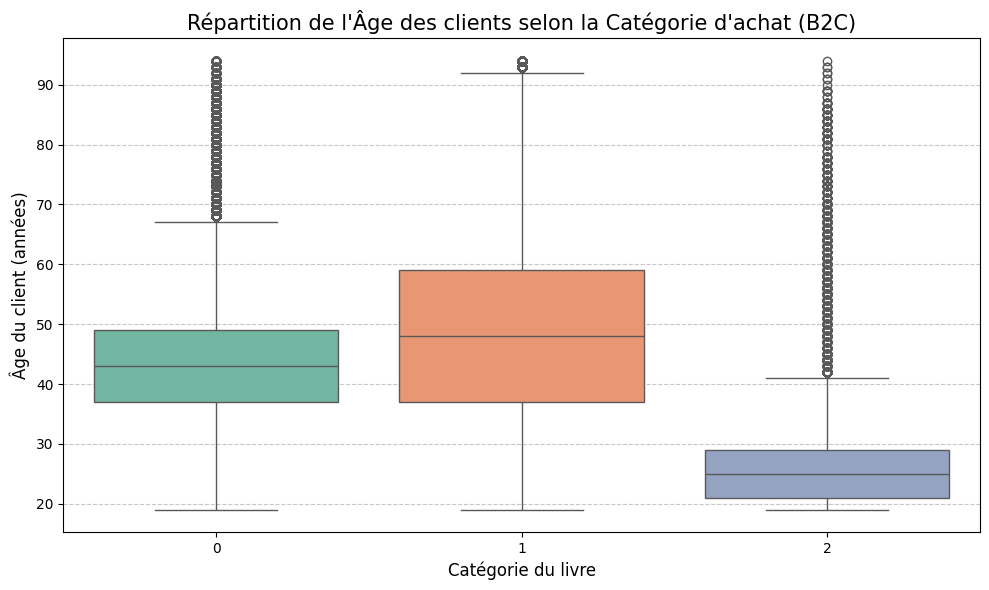

In [98]:
## 4.5 Relation entre l'âge des clients et la catégorie d'achat

# --- 1. Préparation des données ---
# Calcul de l'âge exact sur le périmètre B2C
annee_max = df_b2c['date'].dt.year.max()
df_b2c['age'] = annee_max - df_b2c['birth']

# --- 2. Séparation en groupes et nettoyage ---
# On isole les âges des clients pour chaque catégorie de livre
# On retire immédiatement les valeurs nulles (.dropna()) pour que l'ANOVA fonctionne
ages_cat_0 = df_b2c[df_b2c['categ'] == 0]['age'].dropna()
ages_cat_1 = df_b2c[df_b2c['categ'] == 1]['age'].dropna()
ages_cat_2 = df_b2c[df_b2c['categ'] == 2]['age'].dropna()

# --- 3. Test de l'Analyse de la Variance (ANOVA) ---
f_stat, p_value_anova = st.f_oneway(ages_cat_0, ages_cat_1, ages_cat_2)

print("--- RÉSULTAT DU TEST ANOVA ---")
print(f"Statistique de Fisher : {f_stat:.2f}")
print(f"Valeur p (p-value) : {p_value_anova:.2e}")

# --- 4. Tracé du Boxplot ---
plt.figure(figsize=(10, 6))

# Le boxplot permet de visualiser la médiane et la dispersion des âges par catégorie.
# L'ajout de hue='categ' et legend=False corrige l'avertissement (FutureWarning) de Seaborn.
sns.boxplot(data=df_b2c, x='categ', y='age', hue='categ', palette='Set2', legend=False)

plt.title("Répartition de l'Âge des clients selon la Catégorie d'achat (B2C)", fontsize=15)
plt.xlabel("Catégorie du livre", fontsize=12)
plt.ylabel("Âge du client (années)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()